# 시설물 데이터 전처리 

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

## 1) 데이터 구조 확인 및 스케일링 방법 비교

In [88]:
# final 성남시 데이터 불러오기
final_df = pd.read_csv('./raw-data/5_seongnam_final_dataset.csv')
print(f"shape: {final_df.shape}")
final_df.head()

shape: (142, 25)


,시설물명,위도,경도,도로안전표지,도로적색표면,무단횡단방지펜스,무인교통단속카메라,보호구역표지판,생활안전CCTV,신호등,...,사망및중상자수,사망자수,중상자수,경상자수,총인구수,0~4세,5~9세,10~14세,어린이 총인구,어린이 비율(%)
0,중원초등학교,37.437855,127.167857,0,5,12,0,15,18,0,...,0,0,0,0,36419,596,682,1083,2361,6.482880
1,하원초등학교,37.446255,127.170236,6,7,21,2,15,16,10,...,0,0,0,0,43046,1564,1577,1276,4417,10.261116
2,중부초등학교,37.451546,127.164951,2,19,25,2,26,27,4,...,0,0,0,0,30267,400,549,880,1829,6.042885
3,상대원초등학교,37.442382,127.181591,2,8,30,1,21,5,3,...,0,0,0,0,36419,596,682,1083,2361,6.482880
4,도촌초등학교,37.414730,127.158024,5,9,26,1,10,6,5,...,0,0,0,0,25878,714,1005,1359,3078,11.894273


In [89]:
# feature / target / 제외 컬럼 정의
FACILITY_FEATURES = ['도로안전표지', '도로적색표면', '무단횡단방지펜스', '무인교통단속카메라',
                     '보호구역표지판', '생활안전CCTV', '신호등', '옐로카펫', '횡단보도']

POPULATION_FEATURES_TOTAL = ['총인구수', '0~4세', '5~9세', '10~14세', '어린이 총인구', '어린이 비율(%)']
POPULATION_FEATURES = ['어린이 비율(%)']  # 총인구수
TARGET_COLS = ['발생건수', '사상자수', '사망및중상자수', '사망자수', '중상자수', '경상자수']

FEATURE_COLS = FACILITY_FEATURES + POPULATION_FEATURES
FEATURE_COLS_EXCEPT_TOTAL = FACILITY_FEATURES + POPULATION_FEATURES  # 총인구수 제외

### 1-1. 기초 통계량

In [90]:
from scipy import stats

# 기초 통계량 + 왜도(skewness) + 첨도(kurtosis) 한 번에 요약
summary = final_df[FEATURE_COLS].describe().T
summary['skewness'] = final_df[FEATURE_COLS].skew()
summary['kurtosis'] = final_df[FEATURE_COLS].kurt()
summary['zero_ratio'] = (final_df[FEATURE_COLS] == 0).mean()  # 0 비율

# 왜도 기준 판정
def skew_label(s):
    if abs(s) < 0.5:
        return '대칭'
    elif abs(s) < 1.0:
        return '약간 치우침'
    else:
        return '강하게 치우침'

summary['skew_판정'] = summary['skewness'].apply(skew_label)

summary[['mean', 'std', 'min', 'max', 'skewness', 'kurtosis', 'zero_ratio', 'skew_판정']]

,mean,std,min,max,skewness,kurtosis,zero_ratio,skew_판정
도로안전표지,3.626761,2.457033,0.000000,13.000000,0.547769,0.849854,0.133803,약간 치우침
도로적색표면,9.549296,5.906575,0.000000,30.000000,0.795090,0.727991,0.021127,약간 치우침
무단횡단방지펜스,16.880282,9.978333,0.000000,45.000000,0.380671,-0.484237,0.042254,대칭
무인교통단속카메라,2.077465,1.778811,0.000000,10.000000,1.438140,2.770281,0.140845,강하게 치우침
보호구역표지판,14.704225,9.026980,0.000000,70.000000,2.003206,9.016877,0.007042,강하게 치우침
생활안전CCTV,18.471831,11.659893,2.000000,67.000000,1.410751,2.613937,0.000000,강하게 치우침
신호등,5.253521,3.396779,0.000000,17.000000,0.643567,0.381667,0.063380,약간 치우침
옐로카펫,0.978873,0.811865,0.000000,4.000000,1.006754,1.893471,0.267606,강하게 치우침
횡단보도,3.718310,2.418505,0.000000,10.000000,0.183131,-0.498562,0.133803,대칭
어린이 비율(%),10.283243,3.486593,4.564101,17.447373,0.199390,-0.591975,0.000000,대칭


In [91]:
import os

output_dir = '../preprocessing/outputs'
os.makedirs(output_dir, exist_ok=True)

save_df = summary[['mean', 'std', 'min', 'max', 'skewness', 'kurtosis', 'zero_ratio', 'skew_판정']]
save_df.to_csv(f'{output_dir}/facility_feature_summary.csv', encoding='utf-8-sig')
print(f"저장 완료: {output_dir}/feature_summary.csv")

저장 완료: ../preprocessing/outputs/feature_summary.csv


### 1-2. Feature별 히스토그램 (시설물)

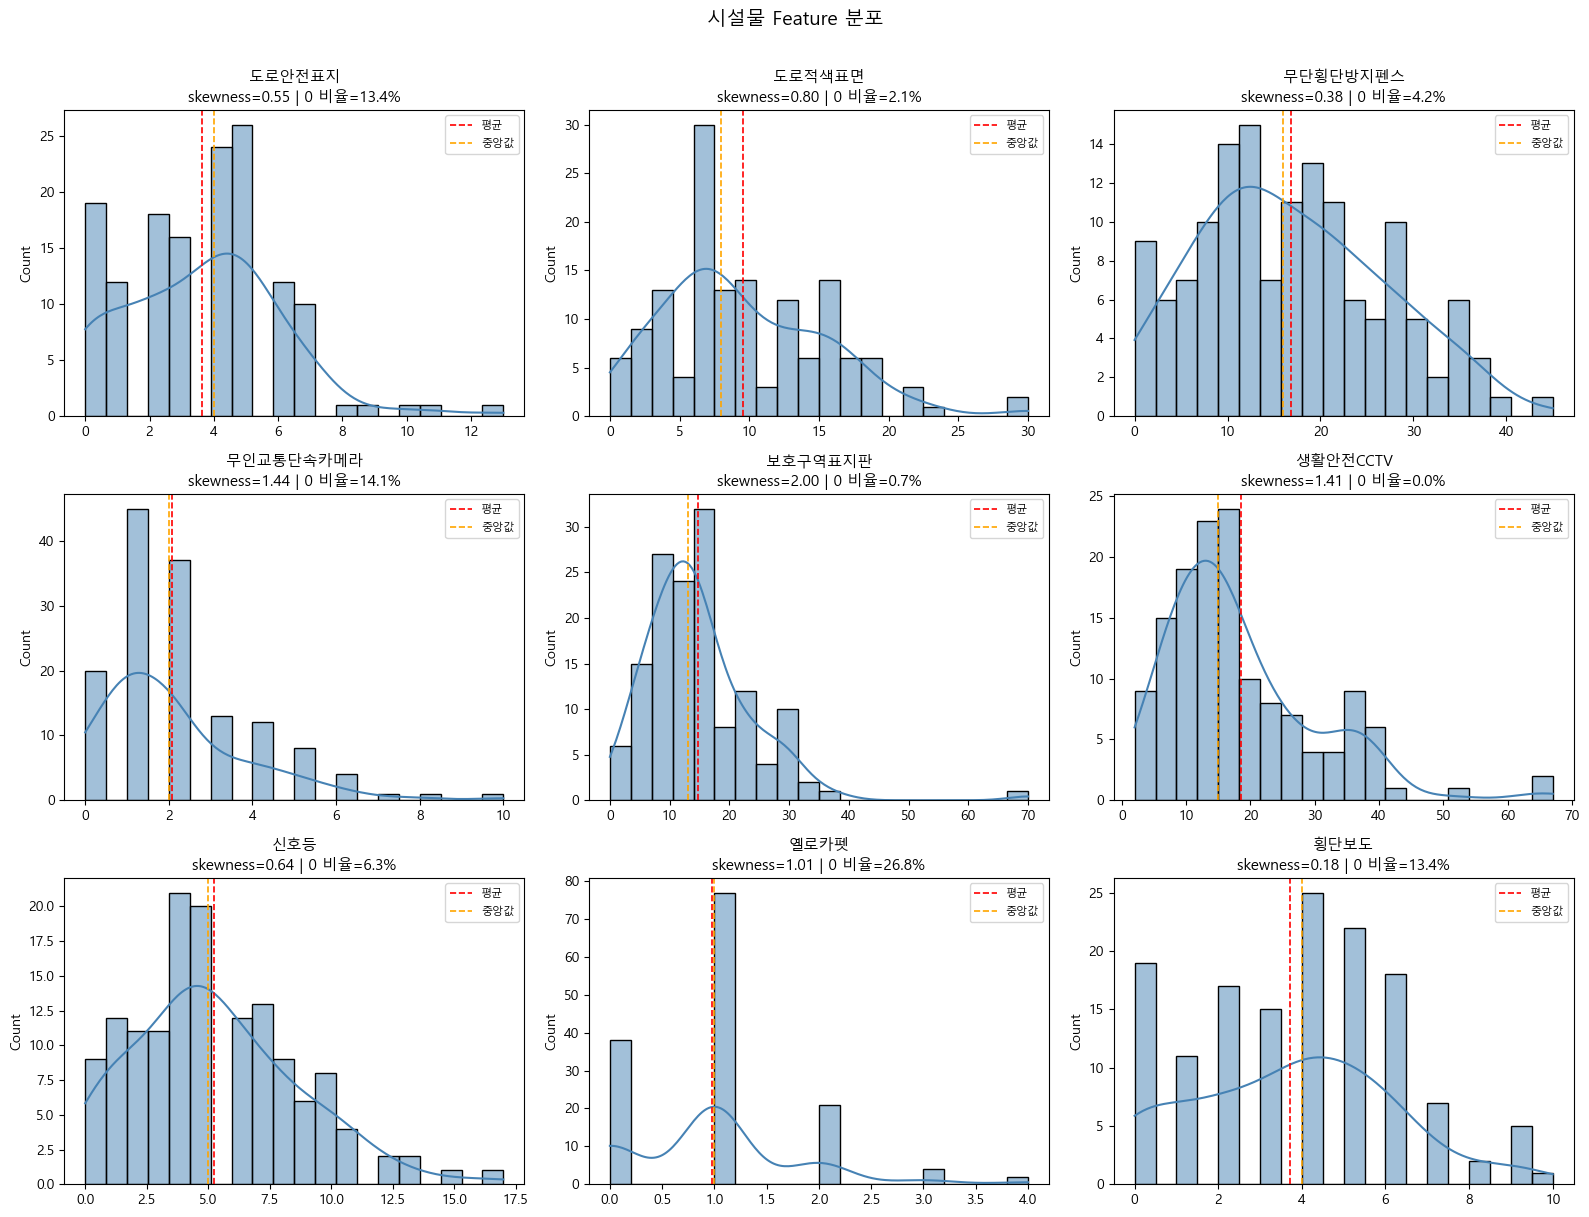

In [92]:
n_cols = 3
n_rows = (len(FACILITY_FEATURES) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(FACILITY_FEATURES):
    ax = axes[i]
    skew_val = final_df[col].skew()
    zero_pct = (final_df[col] == 0).mean() * 100

    sns.histplot(final_df[col], kde=True, bins=20, ax=ax, color='steelblue')

    ax.set_title(f'{col}\nskewness={skew_val:.2f} | 0 비율={zero_pct:.1f}%', fontsize=11)
    ax.set_xlabel('')
    ax.axvline(final_df[col].mean(), color='red', linestyle='--', linewidth=1.2, label='평균')
    ax.axvline(final_df[col].median(), color='orange', linestyle='--', linewidth=1.2, label='중앙값')
    ax.legend(fontsize=8)

# 남는 축 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('시설물 Feature 분포', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [93]:
# 시설물 경향성 플롯 저장
fig_output_dir = '../preprocessing/outputs/visualization'
os.makedirs(fig_output_dir, exist_ok=True)
fig.savefig(f'{fig_output_dir}/facility_feature_distributions.png', bbox_inches='tight', dpi=300)

### 1-3. Feature별 히스토그램 (인구)

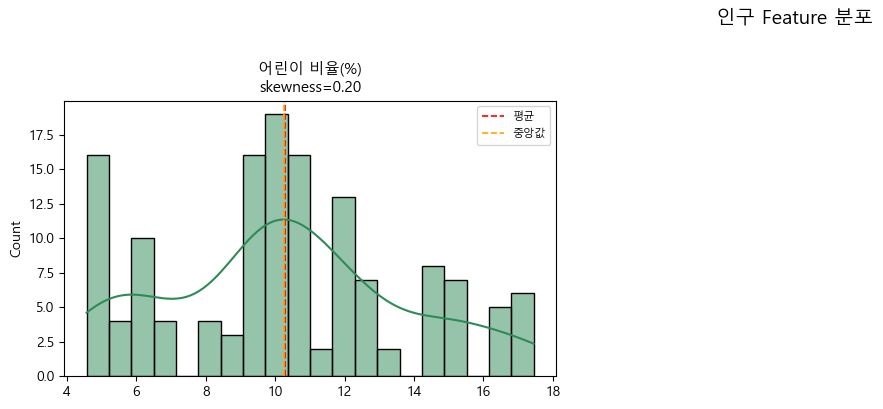

In [94]:
n_cols = 3
n_rows = (len(POPULATION_FEATURES) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(POPULATION_FEATURES):
    ax = axes[i]
    skew_val = final_df[col].skew()

    sns.histplot(final_df[col], kde=True, bins=20, ax=ax, color='seagreen')

    ax.set_title(f'{col}\nskewness={skew_val:.2f}', fontsize=11)
    ax.set_xlabel('')
    ax.axvline(final_df[col].mean(), color='red', linestyle='--', linewidth=1.2, label='평균')
    ax.axvline(final_df[col].median(), color='orange', linestyle='--', linewidth=1.2, label='중앙값')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('인구 Feature 분포', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 1-4. Boxplot으로 이상치 확인

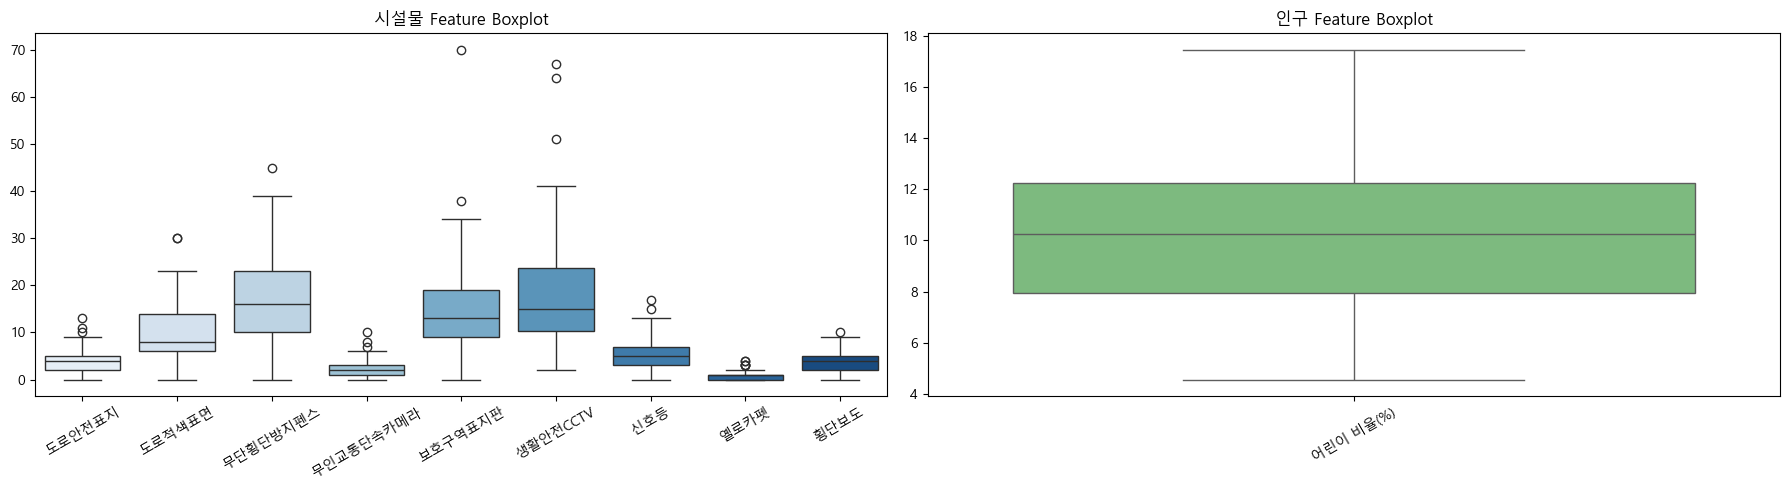


[IQR 기반 이상치 개수]
  도로안전표지              : 3개 (2.1%)
  도로적색표면              : 2개 (1.4%)
  무단횡단방지펜스            : 1개 (0.7%)
  무인교통단속카메라           : 3개 (2.1%)
  보호구역표지판             : 2개 (1.4%)
  생활안전CCTV            : 3개 (2.1%)
  신호등                 : 2개 (1.4%)
  옐로카펫                : 6개 (4.2%)
  횡단보도                : 1개 (0.7%)
  어린이 비율(%)           : 0개 (0.0%)


In [95]:
# 시설물 feature boxplot (이상치 탐지)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 시설물
sns.boxplot(data=final_df[FACILITY_FEATURES], ax=axes[0], palette='Blues')
axes[0].set_title('시설물 Feature Boxplot', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

# 인구 (스케일 차이가 크므로 분리)
sns.boxplot(data=final_df[POPULATION_FEATURES], ax=axes[1], palette='Greens')
axes[1].set_title('인구 Feature Boxplot', fontsize=12)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# IQR 기반 이상치 개수 요약
print("\n[IQR 기반 이상치 개수]")
for col in FEATURE_COLS:
    Q1, Q3 = final_df[col].quantile(0.25), final_df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((final_df[col] < Q1 - 1.5 * IQR) | (final_df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col:20s}: {n_outliers}개 ({n_outliers/len(final_df)*100:.1f}%)")

### 1-5. 정규성 검정 (Shapiro-Wilk)

In [96]:
# Shapiro-Wilk: p-value > 0.05 이면 정규분포로 볼 수 있음
# 샘플 수가 작을 때 적합 (n < 5000)
print(f"데이터 수: {len(final_df)}행\n")
print(f"{'Feature':<25} {'W통계량':>10} {'p-value':>12} {'정규분포?':>10}")
print("-" * 60)

for col in FEATURE_COLS:
    stat, p = stats.shapiro(final_df[col].dropna())
    is_normal = "O" if p > 0.05 else "X"
    print(f"{col:<25} {stat:>10.4f} {p:>12.4f} {is_normal:>10}")

데이터 수: 142행

Feature                         W통계량      p-value      정규분포?
------------------------------------------------------------
도로안전표지                        0.9435       0.0000          X
도로적색표면                        0.9494       0.0000          X
무단횡단방지펜스                      0.9758       0.0128          X
무인교통단속카메라                     0.8573       0.0000          X
보호구역표지판                       0.8713       0.0000          X
생활안전CCTV                      0.8845       0.0000          X
신호등                           0.9597       0.0004          X
옐로카펫                          0.8077       0.0000          X
횡단보도                          0.9555       0.0002          X
어린이 비율(%)                     0.9577       0.0002          X


### 1-6. Feature 간 상관관계 확인

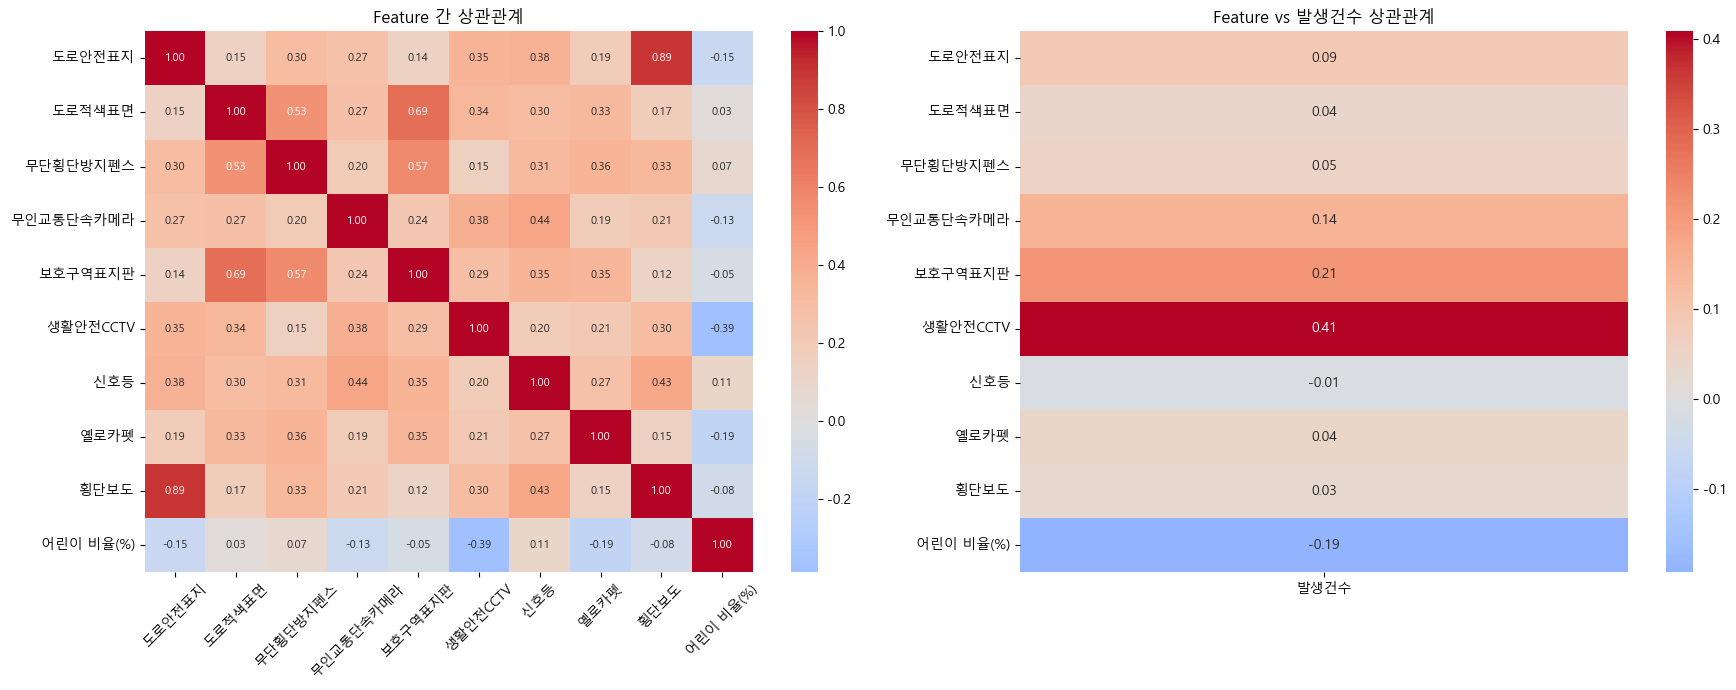

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# feature 간 상관관계
corr_feat = final_df[FEATURE_COLS_EXCEPT_TOTAL].corr()
sns.heatmap(corr_feat, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], annot_kws={'size': 8})
axes[0].set_title('Feature 간 상관관계', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# feature vs 발생건수 상관관계
corr_target = final_df[FEATURE_COLS_EXCEPT_TOTAL + ['발생건수']].corr()[['발생건수']].drop('발생건수')
sns.heatmap(corr_target, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], annot_kws={'size': 10})
axes[1].set_title('Feature vs 발생건수 상관관계', fontsize=12)

plt.tight_layout()
plt.show()

## 2) 데이터 스케일링

### 2-1. 스케일링 대상 분리

In [98]:
from sklearn.preprocessing import StandardScaler

# 1-1 결과 기준: skewness > 1 → Log 변환 후 StandardScaler
LOG_FEATURES = ['무인교통단속카메라', '보호구역표지판', '생활안전CCTV', '옐로카펫']

# 나머지 feature → StandardScaler 바로 적용
STANDARD_FEATURES = [col for col in FEATURE_COLS if col not in LOG_FEATURES]

print("[ Log(x+1) 변환 후 StandardScaler ]")
for col in LOG_FEATURES:
    print(f"  {col}  (skewness={final_df[col].skew():.2f})")

print("\n[ StandardScaler 바로 적용 ]")
for col in STANDARD_FEATURES:
    print(f"  {col}  (skewness={final_df[col].skew():.2f})")

[ Log(x+1) 변환 후 StandardScaler ]
  무인교통단속카메라  (skewness=1.44)
  보호구역표지판  (skewness=2.00)
  생활안전CCTV  (skewness=1.41)
  옐로카펫  (skewness=1.01)

[ StandardScaler 바로 적용 ]
  도로안전표지  (skewness=0.55)
  도로적색표면  (skewness=0.80)
  무단횡단방지펜스  (skewness=0.38)
  신호등  (skewness=0.64)
  횡단보도  (skewness=0.18)
  어린이 비율(%)  (skewness=0.20)


### 2-2. 스케일링 적용

In [99]:
scaled_df = final_df.copy()

# --- Log(x+1) 변환 후 StandardScaler ---
scaler_log = StandardScaler()
log_transformed = np.log1p(scaled_df[LOG_FEATURES])
scaled_df[LOG_FEATURES] = scaler_log.fit_transform(log_transformed)

# --- StandardScaler 바로 적용 ---
scaler_std = StandardScaler()
scaled_df[STANDARD_FEATURES] = scaler_std.fit_transform(scaled_df[STANDARD_FEATURES])

print("스케일링 완료")
print(f"shape: {scaled_df.shape}")
scaled_df[FEATURE_COLS].head()

스케일링 완료
shape: (142, 25)


,도로안전표지,도로적색표면,무단횡단방지펜스,무인교통단속카메라,보호구역표지판,생활안전CCTV,신호등,옐로카펫,횡단보도,어린이 비율(%)
0,-1.481298,-0.772935,-0.490819,-1.744931,0.296887,0.241975,-1.552093,0.226073,-1.542884,-1.093852
1,0.969316,-0.433131,0.414328,0.228100,0.296887,0.052158,1.402293,1.210696,0.946770,-0.006369
2,-0.664427,1.605695,0.816615,0.228100,1.164436,0.903731,-0.370339,0.226073,-0.712999,-1.220495
3,-0.664427,-0.263229,1.319475,-0.500087,0.824886,-1.725175,-0.665777,0.226073,-0.712999,-1.093852
4,0.560880,-0.093327,0.917187,-0.500087,-0.324357,-1.462103,-0.074900,0.226073,0.531827,0.463700


### 2-3. 스케일링 전후 비교

In [100]:
# 스케일링 전후 skewness / mean / std 비교표
compare = pd.DataFrame({
    'skewness_전': final_df[FEATURE_COLS].skew(),
    'skewness_후': scaled_df[FEATURE_COLS].skew(),
    'mean_후':     scaled_df[FEATURE_COLS].mean(),
    'std_후':      scaled_df[FEATURE_COLS].std(),
})
compare['변환방식'] = compare.index.map(
    lambda c: 'Log+Standard' if c in LOG_FEATURES else 'Standard'
)
compare['skewness_개선'] = (compare['skewness_전'].abs() - compare['skewness_후'].abs()).round(3)

compare[['변환방식', 'skewness_전', 'skewness_후', 'skewness_개선', 'mean_후', 'std_후']].round(3)

,변환방식,skewness_전,skewness_후,skewness_개선,mean_후,std_후
도로안전표지,Standard,0.548,0.548,-0.000,0.0,1.004
도로적색표면,Standard,0.795,0.795,-0.000,-0.0,1.004
무단횡단방지펜스,Standard,0.381,0.381,0.000,0.0,1.004
무인교통단속카메라,Log+Standard,1.438,-0.041,1.398,-0.0,1.004
보호구역표지판,Log+Standard,2.003,-0.850,1.153,0.0,1.004
생활안전CCTV,Log+Standard,1.411,-0.137,1.273,0.0,1.004
신호등,Standard,0.644,0.644,0.000,0.0,1.004
옐로카펫,Log+Standard,1.007,-0.157,0.849,-0.0,1.004
횡단보도,Standard,0.183,0.183,-0.000,0.0,1.004
어린이 비율(%),Standard,0.199,0.199,0.000,0.0,1.004


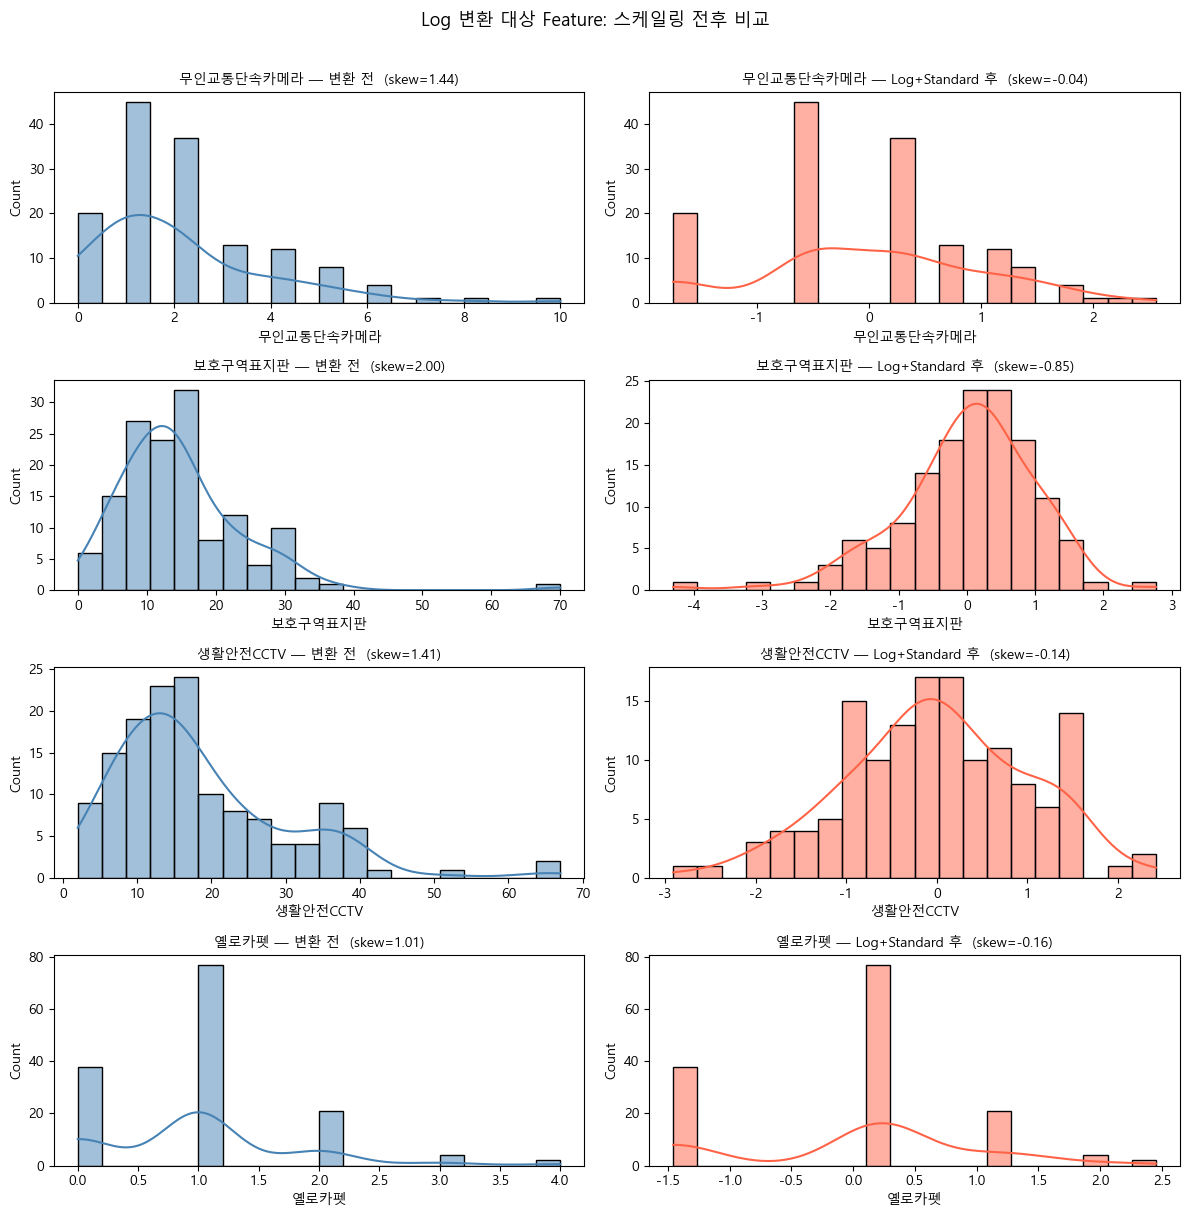

In [101]:
# 스케일링 전후 히스토그램 비교 (LOG_FEATURES만)
fig, axes = plt.subplots(len(LOG_FEATURES), 2, figsize=(12, len(LOG_FEATURES) * 3))

for i, col in enumerate(LOG_FEATURES):
    # 변환 전
    sns.histplot(final_df[col], kde=True, bins=20, ax=axes[i][0], color='steelblue')
    axes[i][0].set_title(f'{col} — 변환 전  (skew={final_df[col].skew():.2f})', fontsize=10)

    # 변환 후
    sns.histplot(scaled_df[col], kde=True, bins=20, ax=axes[i][1], color='tomato')
    axes[i][1].set_title(f'{col} — Log+Standard 후  (skew={scaled_df[col].skew():.2f})', fontsize=10)

plt.suptitle('Log 변환 대상 Feature: 스케일링 전후 비교', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

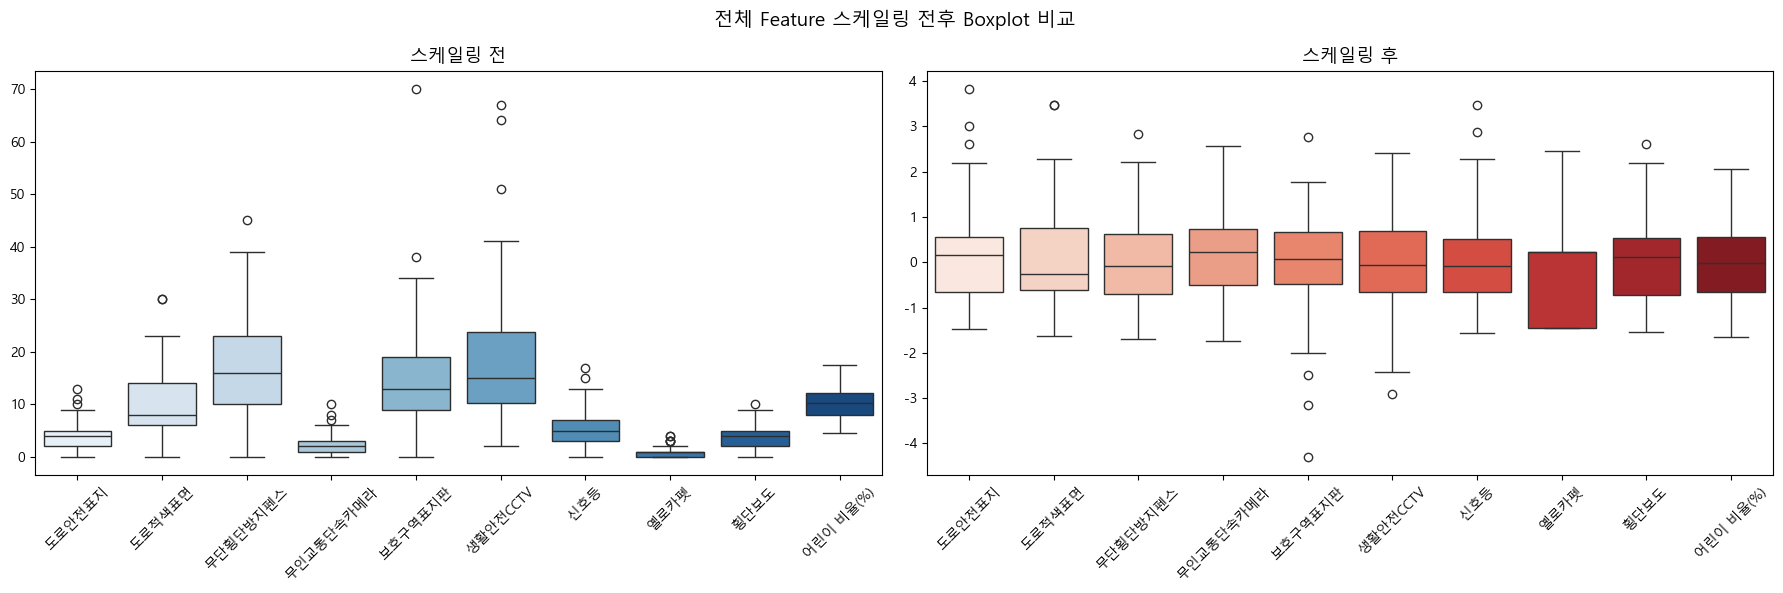

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=final_df[FEATURE_COLS_EXCEPT_TOTAL], ax=axes[0], palette='Blues')
axes[0].set_title('스케일링 전', fontsize=13)
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=scaled_df[FEATURE_COLS_EXCEPT_TOTAL], ax=axes[1], palette='Reds')
axes[1].set_title('스케일링 후', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('전체 Feature 스케일링 전후 Boxplot 비교', fontsize=14)
plt.tight_layout()
plt.show()

### 2-4. 스케일링된 데이터 저장

In [103]:
save_cols = FEATURE_COLS + ['발생건수']
scaled_df[save_cols].to_csv(f'{output_dir}/seongnam_scaled.csv', index=False, encoding='utf-8-sig')
print(f"저장 완료: {output_dir}/seongnam_scaled.csv")
print(f"저장 컬럼: {save_cols}")

저장 완료: ../preprocessing/outputs/seongnam_scaled.csv
저장 컬럼: ['도로안전표지', '도로적색표면', '무단횡단방지펜스', '무인교통단속카메라', '보호구역표지판', '생활안전CCTV', '신호등', '옐로카펫', '횡단보도', '어린이 비율(%)', '발생건수']
